# Computational Graphs: Visualizing Calculations

## Introduction

Before we dive into backpropagation and automatic differentiation, we need to understand **computational graphs** — the foundation that makes gradient-based learning possible.

### What We'll Learn

- How to represent any computation as a **directed acyclic graph (DAG)**
- Why nodes and edges naturally capture the flow of information
- How graphs make complex derivatives tractable through the **chain rule**
- The visual intuition that makes backpropagation obvious

### Why This Matters

Every deep learning framework (PyTorch, TensorFlow, JAX) builds computational graphs under the hood. Understanding these graphs transforms backpropagation from "magic" into an intuitive algorithm for computing gradients.

Let's build this intuition from scratch!

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

from aiml_notebooks import set_seed

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility.

In [2]:
set_seed(42)

## What is a Computation?

At its core, any computation is just a series of simple operations applied to values.

Let's start with the simplest possible example:

In [3]:
# Simple computation: f = a + b
a = 2.0
b = 3.0
f = a + b

print(f"a = {a}")
print(f"b = {b}")
print(f"f = a + b = {f}")

a = 2.0
b = 3.0
f = a + b = 5.0


This is a computation with:
- **Inputs**: `a` and `b`
- **Operation**: addition (`+`)
- **Output**: `f`

But how do we *visualize* this computation?

## Computational Graphs: Nodes and Edges

We can represent any computation as a **graph** where:
- **Nodes** represent values (inputs, intermediates, outputs)
- **Edges** represent the flow of data between operations

For our simple addition `f = a + b`, the graph looks like this:

```
  a     b
   \   /
    \ /
     +
     |
     f
```

Let's create a helper function to draw these graphs:

In [4]:
def draw_computation_graph(nodes, edges, title="Computational Graph", figsize=(10, 6)):
    """
    Draw a computational graph.
    
    Args:
        nodes: List of (name, x, y, node_type) tuples
               node_type can be 'input', 'operation', or 'output'
        edges: List of (from_node, to_node) tuples (indices into nodes list)
        title: Graph title
        figsize: Figure size
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 6.5)
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Color scheme
    colors = {
        'input': '#a8dadc',      # Light blue
        'operation': '#f1faee',  # Off-white
        'output': '#e63946'      # Red
    }
    
    # Draw edges first (so they appear behind nodes)
    for from_idx, to_idx in edges:
        from_x, from_y = nodes[from_idx][1], nodes[from_idx][2]
        to_x, to_y = nodes[to_idx][1], nodes[to_idx][2]
        
        arrow = FancyArrowPatch(
            (from_x, from_y), (to_x, to_y),
            arrowstyle='->', mutation_scale=20, linewidth=2,
            color='#457b9d', alpha=0.7
        )
        ax.add_patch(arrow)
    
    # Draw nodes
    for name, x, y, node_type in nodes:
        # Determine node style based on type
        if node_type == 'operation':
            # Circle for operations
            circle = plt.Circle((x, y), 0.4, color=colors[node_type], 
                              ec='#1d3557', linewidth=2, zorder=3)
            ax.add_patch(circle)
        else:
            # Rectangle for values
            rect = FancyBboxPatch((x-0.4, y-0.3), 0.8, 0.6,
                                boxstyle="round,pad=0.05",
                                facecolor=colors[node_type],
                                edgecolor='#1d3557', linewidth=2, zorder=3)
            ax.add_patch(rect)
        
        # Add text label
        ax.text(x, y, name, ha='center', va='center',
               fontsize=12, fontweight='bold', zorder=4)
    
    # Add legend
    legend_elements = [
        mpatches.Patch(facecolor=colors['input'], edgecolor='#1d3557', label='Input'),
        mpatches.Patch(facecolor=colors['operation'], edgecolor='#1d3557', label='Operation'),
        mpatches.Patch(facecolor=colors['output'], edgecolor='#1d3557', label='Output')
    ]
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

Now let's visualize our simple addition graph:

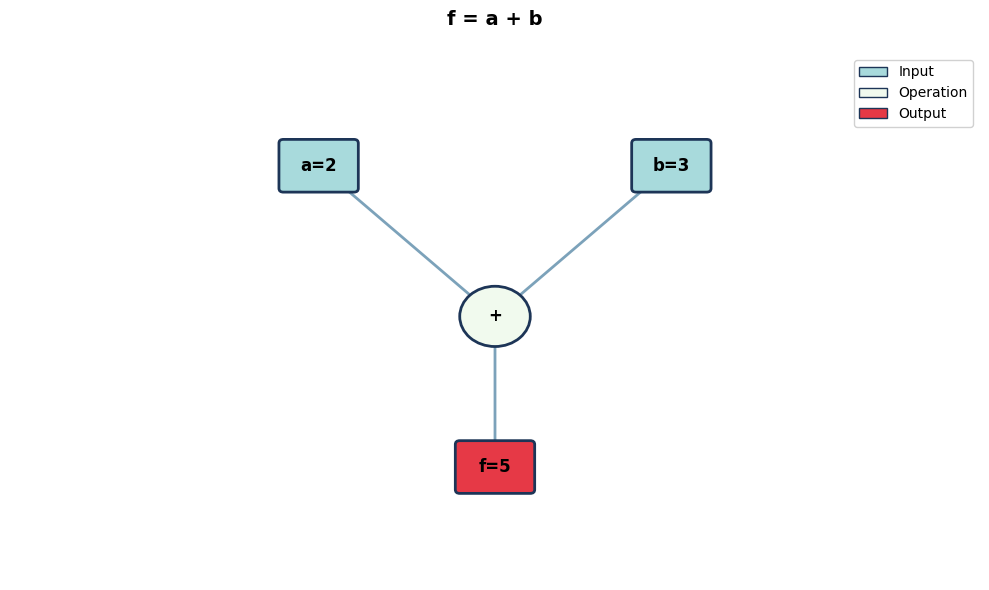

In [5]:
# Define nodes: (name, x_position, y_position, type)
nodes = [
    ('a=2', 3, 5, 'input'),      # Node 0
    ('b=3', 7, 5, 'input'),      # Node 1
    ('+', 5, 3, 'operation'),    # Node 2
    ('f=5', 5, 1, 'output')      # Node 3
]

# Define edges: (from_node_index, to_node_index)
edges = [
    (0, 2),  # a -> +
    (1, 2),  # b -> +
    (2, 3)   # + -> f
]

draw_computation_graph(nodes, edges, title="f = a + b")

### Key Observations

1. **Data flows from top to bottom** (inputs → operations → outputs)
2. **Operations are nodes** that take inputs and produce outputs
3. **Edges show dependencies** — which values are needed for each operation
4. This forms a **directed graph** (arrows have direction)

## Building Slightly More Complex Graphs

Let's try a multiplication operation: `f = a * b`

In [6]:
# Computation: f = a * b
a = 2.0
b = 3.0
f = a * b

print(f"f = {a} * {b} = {f}")

f = 2.0 * 3.0 = 6.0


The graph structure is identical to addition — only the operation changes:

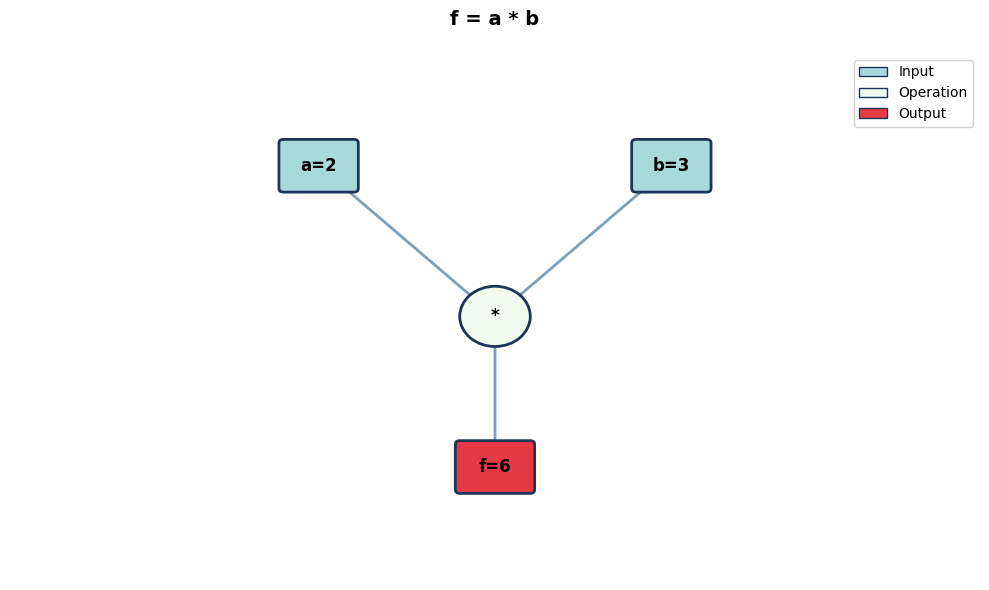

In [7]:
nodes = [
    ('a=2', 3, 5, 'input'),
    ('b=3', 7, 5, 'input'),
    ('*', 5, 3, 'operation'),
    ('f=6', 5, 1, 'output')
]

edges = [
    (0, 2),  # a -> *
    (1, 2),  # b -> *
    (2, 3)   # * -> f
]

draw_computation_graph(nodes, edges, title="f = a * b")

Notice the **pattern**: Different operations, same graph structure. This modularity is powerful!

## Chaining Operations: Multi-Step Computations

Real computations involve multiple operations chained together.

Let's compute: `f = (a + b) * c`

In [8]:
# Multi-step computation
a = 2.0
b = 3.0
c = 4.0

# Step 1: Add a and b
d = a + b
print(f"Step 1: d = a + b = {a} + {b} = {d}")

# Step 2: Multiply result by c
f = d * c
print(f"Step 2: f = d * c = {d} * {c} = {f}")

print(f"\nFinal: f = (a + b) * c = ({a} + {b}) * {c} = {f}")

Step 1: d = a + b = 2.0 + 3.0 = 5.0
Step 2: f = d * c = 5.0 * 4.0 = 20.0

Final: f = (a + b) * c = (2.0 + 3.0) * 4.0 = 20.0


Now we have an **intermediate value** `d` that flows from one operation to the next:

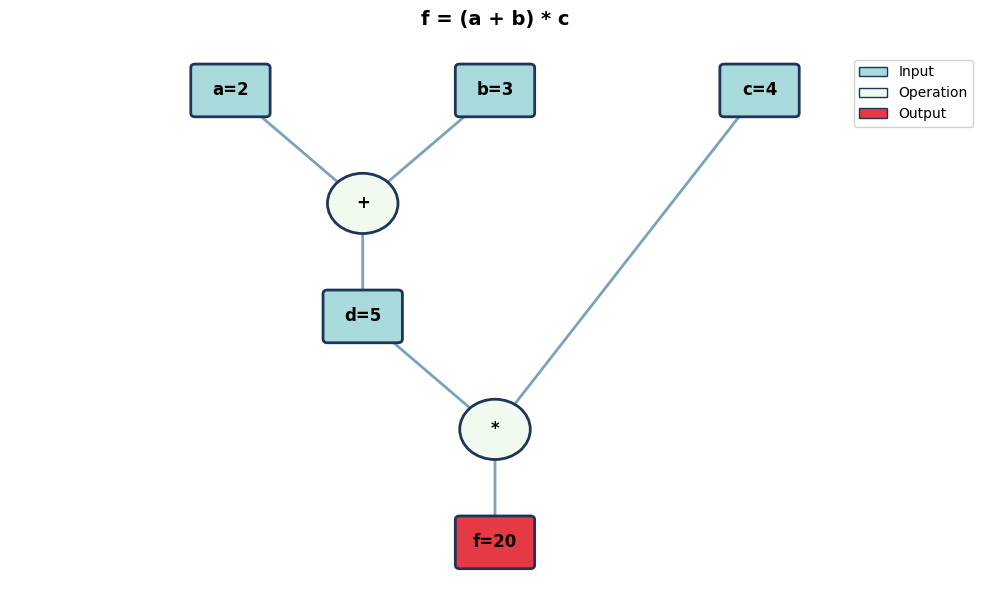

In [9]:
nodes = [
    ('a=2', 2, 6, 'input'),
    ('b=3', 5, 6, 'input'),
    ('c=4', 8, 6, 'input'),
    ('+', 3.5, 4.5, 'operation'),
    ('d=5', 3.5, 3, 'input'),     # Intermediate value
    ('*', 5, 1.5, 'operation'),
    ('f=20', 5, 0, 'output')
]

edges = [
    (0, 3),  # a -> +
    (1, 3),  # b -> +
    (3, 4),  # + -> d
    (4, 5),  # d -> *
    (2, 5),  # c -> *
    (5, 6)   # * -> f
]

draw_computation_graph(nodes, edges, title="f = (a + b) * c")

### The Graph Grows with Computation Complexity

Key insight: **Every intermediate value becomes a node**. The graph naturally captures the entire computation's structure.

## Why "Directed Acyclic Graph" (DAG)?

Computational graphs have two critical properties:

1. **Directed**: Edges have direction (data flows from inputs to outputs)
2. **Acyclic**: No loops — we can't have a value depend on itself

The acyclic property means we can always **topologically sort** the graph — arrange operations in an order where all inputs to an operation are computed before the operation itself.

For our example `f = (a + b) * c`, the execution order is:
1. Start with inputs: `a`, `b`, `c`
2. Compute: `d = a + b`
3. Compute: `f = d * c`

This is called the **forward pass**.

## A More Complex Example

Let's build a graph for a more realistic computation:

$$f = (a \cdot b) + (c \cdot d)$$

This has **two parallel branches** that merge:

In [10]:
# Computation with two branches
a = 2.0
b = 3.0
c = 4.0
d = 5.0

# Branch 1: multiply a and b
e = a * b
print(f"Branch 1: e = a * b = {a} * {b} = {e}")

# Branch 2: multiply c and d
g = c * d
print(f"Branch 2: g = c * d = {c} * {d} = {g}")

# Merge: add the results
f = e + g
print(f"Merge: f = e + g = {e} + {g} = {f}")

print(f"\nFinal: f = (a*b) + (c*d) = ({a}*{b}) + ({c}*{d}) = {f}")

Branch 1: e = a * b = 2.0 * 3.0 = 6.0
Branch 2: g = c * d = 4.0 * 5.0 = 20.0
Merge: f = e + g = 6.0 + 20.0 = 26.0

Final: f = (a*b) + (c*d) = (2.0*3.0) + (4.0*5.0) = 26.0


The computational graph now has **parallel paths** that converge:

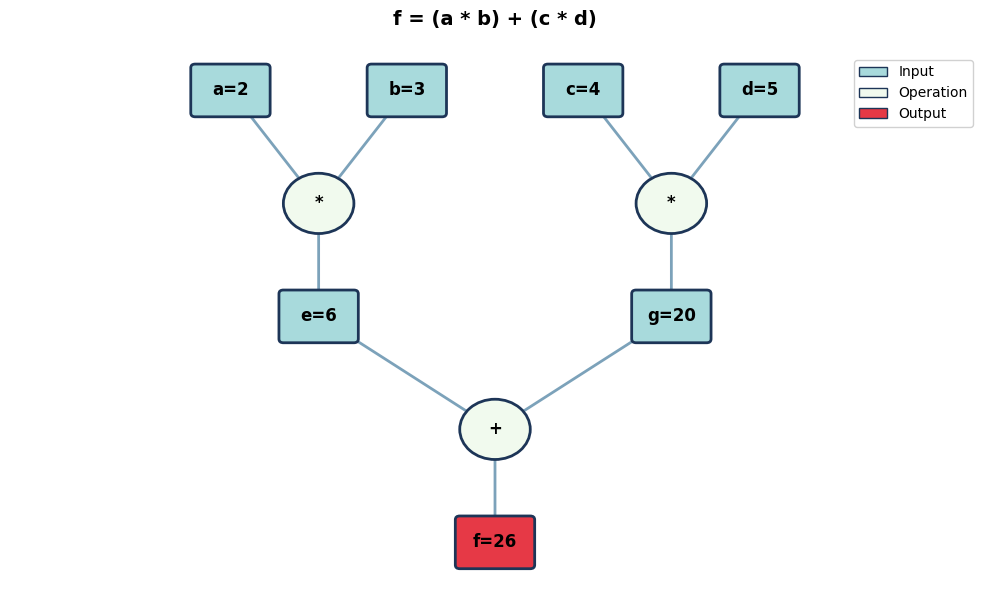

In [11]:
nodes = [
    ('a=2', 2, 6, 'input'),
    ('b=3', 4, 6, 'input'),
    ('c=4', 6, 6, 'input'),
    ('d=5', 8, 6, 'input'),
    ('*', 3, 4.5, 'operation'),
    ('e=6', 3, 3, 'input'),
    ('*', 7, 4.5, 'operation'),
    ('g=20', 7, 3, 'input'),
    ('+', 5, 1.5, 'operation'),
    ('f=26', 5, 0, 'output')
]

edges = [
    (0, 4),  # a -> *
    (1, 4),  # b -> *
    (4, 5),  # * -> e
    (2, 6),  # c -> *
    (3, 6),  # d -> *
    (6, 7),  # * -> g
    (5, 8),  # e -> +
    (7, 8),  # g -> +
    (8, 9)   # + -> f
]

draw_computation_graph(nodes, edges, title="f = (a * b) + (c * d)")

### Parallel Computation

Notice that `e = a * b` and `g = c * d` are **independent** — they could be computed in parallel! This is one reason GPUs (which excel at parallel processing) are so effective for deep learning.

## Why Graphs Help with Differentiation

Now we get to the **crucial insight**: computational graphs make it easy to compute derivatives using the **chain rule**.

Consider `f = (a + b) * c` again. To find how `f` changes with respect to `a` (i.e., $\frac{\partial f}{\partial a}$), we use the chain rule:

$$\frac{\partial f}{\partial a} = \frac{\partial f}{\partial d} \cdot \frac{\partial d}{\partial a}$$

where `d = a + b`.

The graph structure **encodes these dependencies** perfectly:
- To get from `a` to `f`, we must go through `d`
- Each edge represents a local derivative
- The total derivative is the product of local derivatives along the path

### Computing Local Derivatives

Let's compute the local derivatives for `f = (a + b) * c`:

In [12]:
# Our values
a, b, c = 2.0, 3.0, 4.0
d = a + b  # d = 5
f = d * c  # f = 20

# Local derivatives
# For d = a + b:
dd_da = 1.0  # ∂d/∂a = 1
dd_db = 1.0  # ∂d/∂b = 1

# For f = d * c:
df_dd = c    # ∂f/∂d = c = 4.0
df_dc = d    # ∂f/∂c = d = 5.0

print("Local derivatives:")
print(f"∂d/∂a = {dd_da}")
print(f"∂d/∂b = {dd_db}")
print(f"∂f/∂d = {df_dd}")
print(f"∂f/∂c = {df_dc}")

Local derivatives:
∂d/∂a = 1.0
∂d/∂b = 1.0
∂f/∂d = 4.0
∂f/∂c = 5.0


### Applying the Chain Rule

Now we can compute how `f` depends on each input using the chain rule:

In [13]:
# Chain rule: ∂f/∂a = (∂f/∂d) * (∂d/∂a)
df_da = df_dd * dd_da
print(f"∂f/∂a = (∂f/∂d) * (∂d/∂a) = {df_dd} * {dd_da} = {df_da}")

# Chain rule: ∂f/∂b = (∂f/∂d) * (∂d/∂b)
df_db = df_dd * dd_db
print(f"∂f/∂b = (∂f/∂d) * (∂d/∂b) = {df_dd} * {dd_db} = {df_db}")

# Direct: ∂f/∂c (no chain needed)
print(f"∂f/∂c = {df_dc}")

∂f/∂a = (∂f/∂d) * (∂d/∂a) = 4.0 * 1.0 = 4.0
∂f/∂b = (∂f/∂d) * (∂d/∂b) = 4.0 * 1.0 = 4.0
∂f/∂c = 5.0


Let's verify these derivatives numerically using finite differences:

In [14]:
def f_func(a, b, c):
    """Our function: f = (a + b) * c"""
    return (a + b) * c

# Numerical derivatives using finite differences
h = 1e-5  # Small step

# ∂f/∂a ≈ (f(a+h, b, c) - f(a, b, c)) / h
df_da_numerical = (f_func(a + h, b, c) - f_func(a, b, c)) / h

# ∂f/∂b ≈ (f(a, b+h, c) - f(a, b, c)) / h
df_db_numerical = (f_func(a, b + h, c) - f_func(a, b, c)) / h

# ∂f/∂c ≈ (f(a, b, c+h) - f(a, b, c)) / h
df_dc_numerical = (f_func(a, b, c + h) - f_func(a, b, c)) / h

print("\nVerification (Analytical vs Numerical):")
print(f"∂f/∂a: {df_da:.6f} vs {df_da_numerical:.6f}")
print(f"∂f/∂b: {df_db:.6f} vs {df_db_numerical:.6f}")
print(f"∂f/∂c: {df_dc:.6f} vs {df_dc_numerical:.6f}")


Verification (Analytical vs Numerical):
∂f/∂a: 4.000000 vs 4.000000
∂f/∂b: 4.000000 vs 4.000000
∂f/∂c: 5.000000 vs 5.000000


Perfect match! The chain rule through the computational graph gives us **exact** derivatives.

## Visualizing the Backward Pass

The **backward pass** (backpropagation) flows gradients from the output back to the inputs, following the graph structure in reverse.

Let's visualize this for `f = (a + b) * c`:

**Forward pass** (compute values, top to bottom):
- Given: `a=2`, `b=3`, `c=4`
- Compute: `d = a + b = 5`
- Compute: `f = d * c = 20`

**Backward pass** (compute gradients, bottom to top):
- Start with: $\frac{\partial f}{\partial f} = 1$ (gradient of output w.r.t. itself)
- Compute: $\frac{\partial f}{\partial d} = c = 4$ and $\frac{\partial f}{\partial c} = d = 5$
- Compute: $\frac{\partial f}{\partial a} = \frac{\partial f}{\partial d} \cdot 1 = 4$ and $\frac{\partial f}{\partial b} = \frac{\partial f}{\partial d} \cdot 1 = 4$

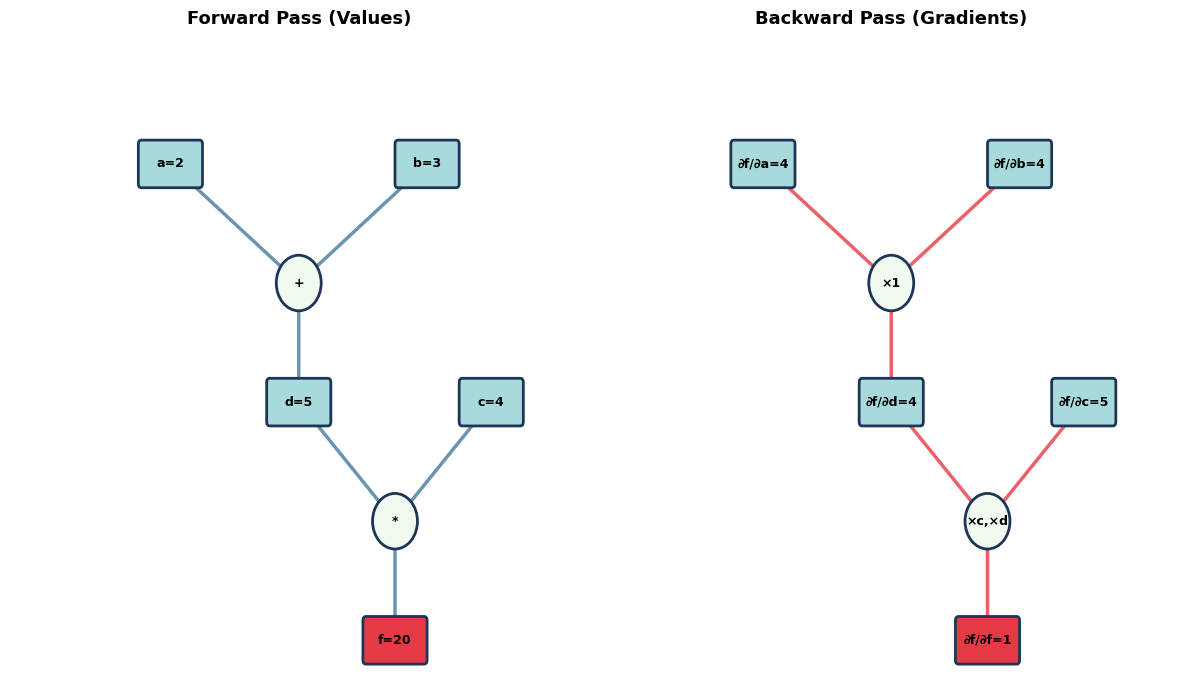

In [15]:
def draw_backward_pass(figsize=(12, 7)):
    """
    Draw computational graph showing both forward and backward pass.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    for ax, title, show_gradients in [(ax1, "Forward Pass (Values)", False),
                                      (ax2, "Backward Pass (Gradients)", True)]:
        ax.set_xlim(-0.5, 8.5)
        ax.set_ylim(-0.5, 7.5)
        ax.axis('off')
        ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
        
        if not show_gradients:
            # Forward pass - show values
            nodes_data = [
                ('a=2', 2, 6, 'input'),
                ('b=3', 6, 6, 'input'),
                ('c=4', 7, 3, 'input'),
                ('+', 4, 4.5, 'operation'),
                ('d=5', 4, 3, 'input'),
                ('*', 5.5, 1.5, 'operation'),
                ('f=20', 5.5, 0, 'output')
            ]
            arrow_color = '#457b9d'
            edges_to_draw = [(0, 3), (1, 3), (3, 4), (4, 5), (2, 5), (5, 6)]
        else:
            # Backward pass - show gradients
            nodes_data = [
                ('∂f/∂a=4', 2, 6, 'input'),
                ('∂f/∂b=4', 6, 6, 'input'),
                ('∂f/∂c=5', 7, 3, 'input'),
                ('×1', 4, 4.5, 'operation'),
                ('∂f/∂d=4', 4, 3, 'input'),
                ('×c,×d', 5.5, 1.5, 'operation'),
                ('∂f/∂f=1', 5.5, 0, 'output')
            ]
            arrow_color = '#e63946'
            # Reversed edges for backward pass
            edges_to_draw = [(6, 5), (5, 4), (5, 2), (4, 3), (3, 0), (3, 1)]
        
        # Draw edges
        for from_idx, to_idx in edges_to_draw:
            from_x, from_y = nodes_data[from_idx][1], nodes_data[from_idx][2]
            to_x, to_y = nodes_data[to_idx][1], nodes_data[to_idx][2]
            
            arrow = FancyArrowPatch(
                (from_x, from_y), (to_x, to_y),
                arrowstyle='->', mutation_scale=15, linewidth=2.5,
                color=arrow_color, alpha=0.8
            )
            ax.add_patch(arrow)
        
        # Draw nodes
        colors = {'input': '#a8dadc', 'operation': '#f1faee', 'output': '#e63946'}
        for name, x, y, node_type in nodes_data:
            if node_type == 'operation':
                circle = plt.Circle((x, y), 0.35, color=colors[node_type],
                                  ec='#1d3557', linewidth=2, zorder=3)
                ax.add_patch(circle)
            else:
                rect = FancyBboxPatch((x-0.45, y-0.25), 0.9, 0.5,
                                    boxstyle="round,pad=0.05",
                                    facecolor=colors[node_type],
                                    edgecolor='#1d3557', linewidth=2, zorder=3)
                ax.add_patch(rect)
            
            ax.text(x, y, name, ha='center', va='center',
                   fontsize=9, fontweight='bold', zorder=4)
    
    plt.tight_layout()
    plt.show()

draw_backward_pass()

### Key Insight

The computational graph provides a **blueprint** for both:
1. **Forward pass**: Compute the output (follow edges forward)
2. **Backward pass**: Compute gradients (follow edges backward, applying chain rule)

This is the foundation of **automatic differentiation** — frameworks like PyTorch build these graphs automatically and compute gradients for us!

## More Complex Example: Neural Network Layer

Let's see how this applies to a simple neural network operation:

$$y = \text{ReLU}(w \cdot x + b)$$

where ReLU(z) = max(0, z).

In [16]:
# Simple neuron computation
x = 2.0   # Input
w = 0.5   # Weight
b = 1.0   # Bias

# Forward pass
z = w * x + b
y = max(0, z)  # ReLU activation

print(f"Input: x = {x}")
print(f"Weight: w = {w}")
print(f"Bias: b = {b}")
print(f"\nLinear: z = w*x + b = {w}*{x} + {b} = {z}")
print(f"ReLU: y = max(0, z) = max(0, {z}) = {y}")

Input: x = 2.0
Weight: w = 0.5
Bias: b = 1.0

Linear: z = w*x + b = 0.5*2.0 + 1.0 = 2.0
ReLU: y = max(0, z) = max(0, 2.0) = 2.0


The computational graph for this neuron:

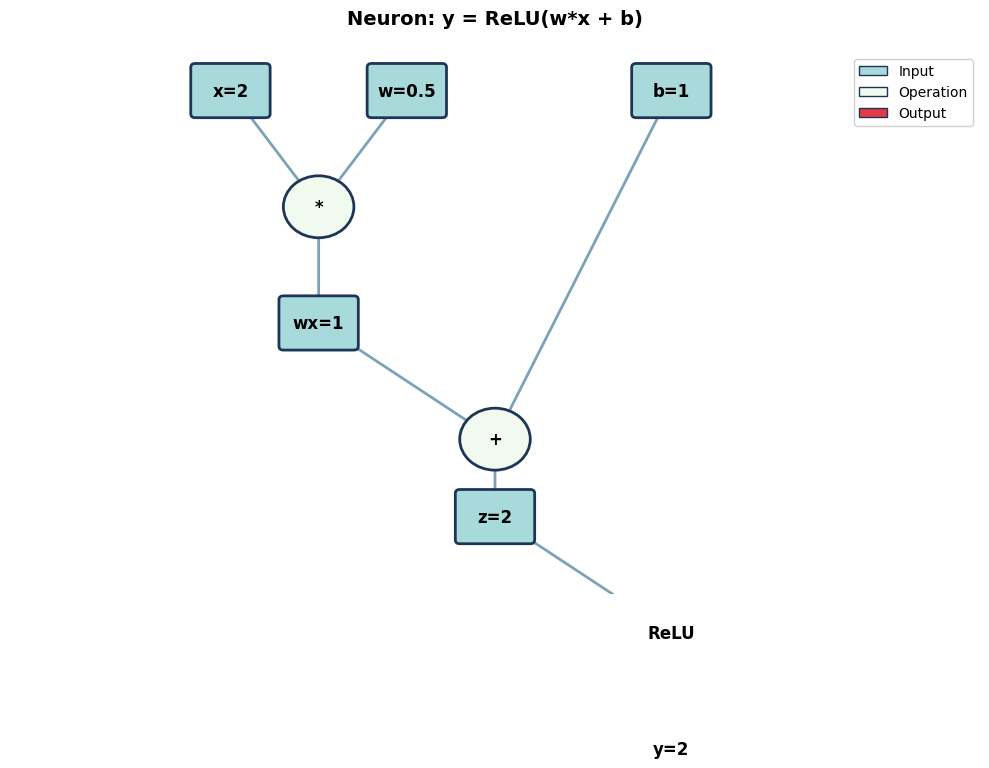

In [17]:
nodes = [
    ('x=2', 2, 6, 'input'),
    ('w=0.5', 4, 6, 'input'),
    ('b=1', 7, 6, 'input'),
    ('*', 3, 4.5, 'operation'),
    ('wx=1', 3, 3, 'input'),
    ('+', 5, 1.5, 'operation'),
    ('z=2', 5, 0.5, 'input'),
    ('ReLU', 7, -1, 'operation'),
    ('y=2', 7, -2.5, 'output')
]

edges = [
    (0, 3),  # x -> *
    (1, 3),  # w -> *
    (3, 4),  # * -> wx
    (4, 5),  # wx -> +
    (2, 5),  # b -> +
    (5, 6),  # + -> z
    (6, 7),  # z -> ReLU
    (7, 8)   # ReLU -> y
]

draw_computation_graph(nodes, edges, title="Neuron: y = ReLU(w*x + b)", figsize=(10, 8))

### Scaling to Neural Networks

A neural network is just **many of these graphs combined**:
- Each neuron has its own graph structure
- Layers connect these neurons
- The entire network is one massive computational graph

When we train a neural network:
1. **Forward pass**: Compute predictions by flowing data through the graph
2. **Compute loss**: Compare predictions to targets
3. **Backward pass**: Flow gradients backward through the graph to update weights

All of this is managed automatically by the computational graph!

## The Power of Computational Graphs: Automatic Differentiation

Let's compare manual derivative computation vs using PyTorch's automatic differentiation:

In [18]:
import torch

# Manual computation
print("=== Manual Computation ===")
a_manual = 2.0
b_manual = 3.0
c_manual = 4.0

d_manual = a_manual + b_manual
f_manual = d_manual * c_manual

# Manual gradients (we computed these earlier)
df_dc_manual = d_manual  # ∂f/∂c = d
df_da_manual = c_manual  # ∂f/∂a = c
df_db_manual = c_manual  # ∂f/∂b = c

print(f"f = {f_manual}")
print(f"∂f/∂a = {df_da_manual}")
print(f"∂f/∂b = {df_db_manual}")
print(f"∂f/∂c = {df_dc_manual}")

=== Manual Computation ===
f = 20.0
∂f/∂a = 4.0
∂f/∂b = 4.0
∂f/∂c = 5.0


In [19]:
# PyTorch automatic differentiation
print("\n=== PyTorch Automatic Differentiation ===")

# Create tensors with gradient tracking
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
c = torch.tensor(4.0, requires_grad=True)

# Forward pass (PyTorch builds the graph automatically!)
d = a + b
f = d * c

print(f"f = {f.item()}")

# Backward pass (PyTorch computes all gradients automatically!)
f.backward()

print(f"∂f/∂a = {a.grad.item()}")
print(f"∂f/∂b = {b.grad.item()}")
print(f"∂f/∂c = {c.grad.item()}")


=== PyTorch Automatic Differentiation ===
f = 20.0
∂f/∂a = 4.0
∂f/∂b = 4.0
∂f/∂c = 5.0


**Identical results!** PyTorch:
1. Built the computational graph during the forward pass
2. Applied the chain rule automatically during `f.backward()`
3. Stored gradients in each tensor's `.grad` attribute

This is the magic that makes deep learning practical — we define the computation, and the framework handles all derivatives!

## Visualizing PyTorch's Computational Graph

PyTorch actually builds a graph data structure. We can peek at it:

In [20]:
# Create a new computation
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Build graph
z = x + y
out = z * 2

print("Computation: out = (x + y) * 2")
print(f"\nResult: out = {out.item()}")
print(f"\nGraph structure:")
print(f"out.grad_fn: {out.grad_fn}")
print(f"out.grad_fn.next_functions: {out.grad_fn.next_functions}")

Computation: out = (x + y) * 2

Result: out = 10.0

Graph structure:
out.grad_fn: <MulBackward0 object at 0x7ef8d77cefb0>
out.grad_fn.next_functions: ((<AddBackward0 object at 0x7ef8d77cf460>, 0), (None, 0))


The `grad_fn` attribute stores the operation that created this tensor — this is how PyTorch tracks the computational graph!

## Experiment: Gradient Flow in Deep Networks

Let's build a chain of operations and see how gradients flow through it.

We'll create: `f = ((x * 2) + 3) * 4`

In [21]:
# Build a chain of operations
x = torch.tensor(1.0, requires_grad=True)

# Chain: multiply, add, multiply
a = x * 2
b = a + 3
c = b * 4

print("Forward pass:")
print(f"x = {x.item()}")
print(f"a = x * 2 = {a.item()}")
print(f"b = a + 3 = {b.item()}")
print(f"c = b * 4 = {c.item()}")

# Compute gradients
c.backward()

print(f"\nBackward pass:")
print(f"∂c/∂x = {x.grad.item()}")

# Manual calculation: ∂c/∂x = ∂c/∂b * ∂b/∂a * ∂a/∂x
dc_db = 4  # ∂c/∂b = 4
db_da = 1  # ∂b/∂a = 1
da_dx = 2  # ∂a/∂x = 2

dc_dx_manual = dc_db * db_da * da_dx
print(f"Manual: ∂c/∂x = {dc_db} * {db_da} * {da_dx} = {dc_dx_manual}")

Forward pass:
x = 1.0
a = x * 2 = 2.0
b = a + 3 = 5.0
c = b * 4 = 20.0

Backward pass:
∂c/∂x = 8.0
Manual: ∂c/∂x = 4 * 1 * 2 = 8


The gradient flows through the chain, multiplying local derivatives at each step — exactly as the chain rule dictates!

## What About Branching Gradients?

What happens when a variable is used multiple times? Let's try:

`f = x * x` (i.e., $f = x^2$)

In [22]:
x = torch.tensor(3.0, requires_grad=True)

# x is used twice
f = x * x

print(f"f = x * x = {x.item()} * {x.item()} = {f.item()}")

# Compute gradient
f.backward()

print(f"\n∂f/∂x = {x.grad.item()}")
print(f"Expected (2*x): {2 * x.item()}")

f = x * x = 3.0 * 3.0 = 9.0

∂f/∂x = 6.0
Expected (2*x): 6.0


Perfect! When a variable is used multiple times, gradients **accumulate** from all paths. For $f = x \cdot x$:

$$\frac{\partial f}{\partial x} = \frac{\partial (x \cdot x)}{\partial x} = x + x = 2x$$

The computational graph tracks both uses and sums the gradients.

## Visualizing a Branching Graph

Let's visualize a computation where `x` branches to multiple operations:

`f = (x * 2) + (x * 3)`

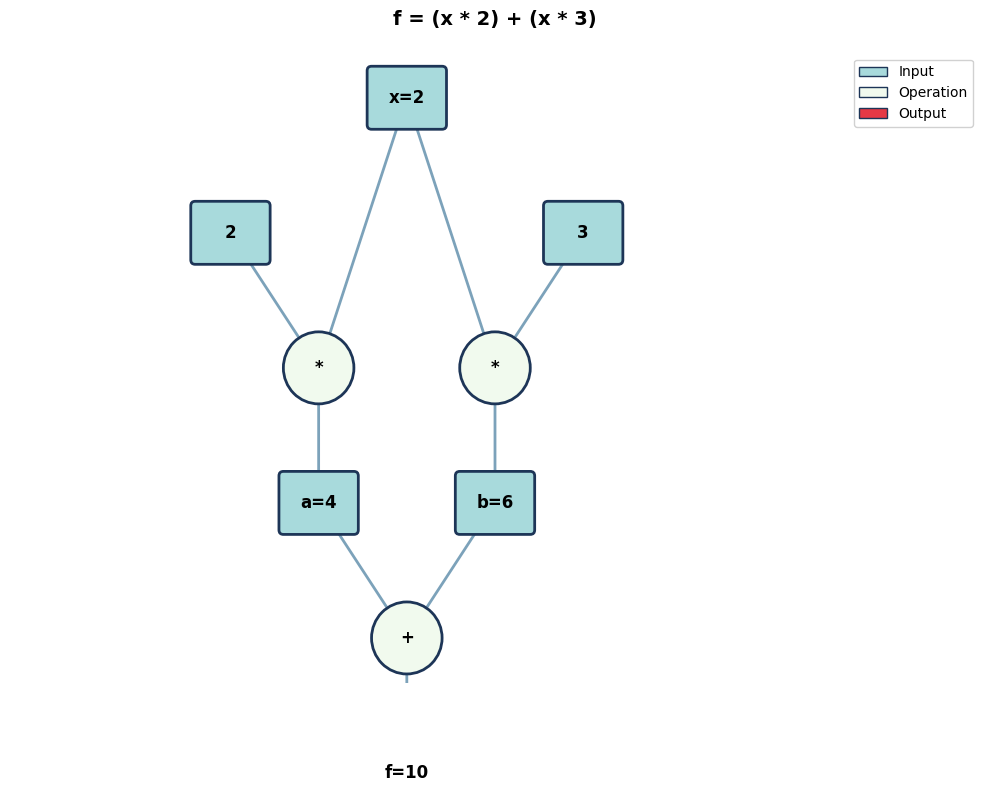

In [23]:
nodes = [
    ('x=2', 4, 6, 'input'),
    ('2', 2, 4.5, 'input'),
    ('3', 6, 4.5, 'input'),
    ('*', 3, 3, 'operation'),
    ('*', 5, 3, 'operation'),
    ('a=4', 3, 1.5, 'input'),
    ('b=6', 5, 1.5, 'input'),
    ('+', 4, 0, 'operation'),
    ('f=10', 4, -1.5, 'output')
]

edges = [
    (0, 3),  # x -> * (left)
    (1, 3),  # 2 -> *
    (0, 4),  # x -> * (right)
    (2, 4),  # 3 -> *
    (3, 5),  # * -> a
    (4, 6),  # * -> b
    (5, 7),  # a -> +
    (6, 7),  # b -> +
    (7, 8)   # + -> f
]

draw_computation_graph(nodes, edges, title="f = (x * 2) + (x * 3)", figsize=(10, 8))

Notice how `x` has **two outgoing edges** — it contributes to both multiplication operations. During backprop, gradients from both paths flow back to `x` and are summed.

Let's verify with PyTorch:

In [24]:
x = torch.tensor(2.0, requires_grad=True)

# Two branches
a = x * 2
b = x * 3
f = a + b

print(f"f = (x*2) + (x*3) = ({x.item()}*2) + ({x.item()}*3) = {f.item()}")

f.backward()

print(f"\n∂f/∂x = {x.grad.item()}")
print(f"Expected (2 + 3): {2 + 3}")
print("\nGradients from both branches summed!")

f = (x*2) + (x*3) = (2.0*2) + (2.0*3) = 10.0

∂f/∂x = 5.0
Expected (2 + 3): 5

Gradients from both branches summed!


## Key Takeaways

### What We Learned

1. **Computational graphs represent any calculation as a DAG**
   - Nodes: values (inputs, intermediates, outputs)
   - Edges: data flow and dependencies
   - Acyclic: no feedback loops

2. **Graphs naturally encode the chain rule**
   - Forward pass: compute values (follow edges forward)
   - Backward pass: compute gradients (follow edges backward)
   - Local derivatives at each operation multiply along paths

3. **Automatic differentiation builds these graphs automatically**
   - PyTorch tracks operations during forward pass
   - `.backward()` propagates gradients through the graph
   - We get exact derivatives without manual calculus!

4. **Branching graphs accumulate gradients**
   - When a variable is used multiple times, gradients sum
   - This emerges naturally from the chain rule

### Why This Matters

Understanding computational graphs transforms backpropagation from a mysterious algorithm into an **obvious consequence** of:
- Representing computations as graphs
- Applying the chain rule systematically

This foundation makes the next notebook — building backpropagation from scratch — much more intuitive!

## Connection to Neural Networks

Every neural network is a computational graph:

- **Inputs**: Data (images, text, etc.)
- **Operations**: Matrix multiplications, activations, normalization
- **Outputs**: Predictions
- **Loss**: Measures prediction error (final node)

Training a neural network:
1. **Forward pass**: Compute predictions and loss
2. **Backward pass**: Compute $\frac{\partial \text{Loss}}{\partial w}$ for every weight $w$
3. **Update**: Adjust weights in the direction that reduces loss

All of this is enabled by the computational graph structure!

**Next up**: We'll build our own autograd engine from scratch to see exactly how PyTorch computes these gradients.

## Bonus: Dynamic vs Static Graphs

Different frameworks handle computational graphs differently:

### Dynamic Graphs (PyTorch, JAX)
- Graph is built **during execution** ("define-by-run")
- Different forward pass can create different graphs
- More flexible: if statements, loops, etc.
- Easier debugging (Python execution flow)

### Static Graphs (TensorFlow 1.x, ONNX)
- Graph is defined **before execution** ("define-and-run")
- Same graph structure every time
- Optimizations possible (graph can be analyzed and optimized)
- More efficient for deployment

PyTorch started with dynamic graphs and added static graph compilation later (`torch.compile`) — giving us the best of both worlds!